# Optimizing the Interaction Matrix for a Target Number of Phases

Find a symmetric interaction matrix $\chi$ for 16 components that gives six coexisting phases. The notebook first shapes the Hessian spectrum, then optionally refines the result through the simulation.

In [1]:
# Colab setup:
# from google.colab import drive
# drive.mount('/content/drive')
#
# import sys
# sys.path.insert(0, '/content/drive/MyDrive/phase_separation')
#
# !cp -r "/content/drive/MyDrive/phase_separation" /content/phase_separation
# %cd phase_separation
# !ls
# !pip install -r requirements.txt
# !pip install jax-tqdm scikit-learn

import os
import sys

sys.path.insert(0, os.path.abspath('../..'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/phase_separation


In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from jax_phase_separation.solver import SimulationParams, simulate, simulate_with_snapshots
from jax_phase_separation.free_energy import compute_jacobian
from jax_phase_separation.utils import (
    generate_initial_conditions, plot_volume_fractions,
    plot_phase_map, plot_partition_ratios,
)
from jax_phase_separation.analysis import analyse_snapshot

print('JAX version:', jax.__version__)
print('Devices:', jax.devices())

JAX version: 0.7.2
Devices: [CudaDevice(id=0)]


## 1. Setup and parametrization

$\chi$ is symmetric with zero diagonal, so we parametrize it by its
$N(N{-}1)/2$ upper-triangular elements.  The optimizer works on this
flat vector; we reconstruct the full matrix inside the loss.

In [3]:
N_COM = 16
N_GRID = 64
BETA = N_COM / (N_COM + 1.0)
DT = 5e-6
LMBDA = 0.01
TARGET_PHASES = 6
TARGET_NEG = TARGET_PHASES - 1  # unstable modes needed

n_upper = N_COM * (N_COM - 1) // 2
print(f'Components: {N_COM}, free parameters: {n_upper}')
print(f'Target: {TARGET_PHASES} phases ({TARGET_NEG} unstable modes)')

Components: 16, free parameters: 120
Target: 6 phases (5 unstable modes)


In [4]:
triu_rows, triu_cols = jnp.triu_indices(N_COM, k=1)

def chi_from_upper(upper_tri):
    """Reconstruct symmetric zero-diagonal chi from upper-triangle vector."""
    chi = jnp.zeros((N_COM, N_COM))
    chi = chi.at[triu_rows, triu_cols].set(upper_tri)
    return chi + chi.T

### Initial (random) interaction matrix

We start from a random $\chi$ drawn the same way as the demo notebook
and check how many eigenvalues of the Hessian $J$ are negative.

In [5]:
key = jax.random.PRNGKey(7)
k_chi, k_ic = jax.random.split(key)

SIGMA_INIT = 4.8
raw = SIGMA_INIT * jax.random.normal(k_chi, (N_COM, N_COM))
chi_init_full = (raw + raw.T) / 2.0
chi_init_full = chi_init_full.at[jnp.diag_indices(N_COM)].set(0.0)
upper_init = chi_init_full[triu_rows, triu_cols]

chi_s_zero = jnp.zeros(N_COM)
r_ones = jnp.ones(N_COM)

J_init = compute_jacobian(N_COM, BETA, chi_init_full, chi_s_zero, r_ones)
w_init = jnp.linalg.eigvalsh(J_init)
n_neg_init = int(jnp.sum(w_init < 0))

print(f'Initial unstable modes: {n_neg_init}  (want {TARGET_NEG})')
print(f'Eigenvalues: {np.array(w_init).round(2)}')

Initial unstable modes: 1  (want 5)
Eigenvalues: [ -3.13   1.66   2.69   5.79   8.5   10.48  12.87  16.6   19.12  21.55
  23.4   26.79  32.72  34.58  36.63 293.77]


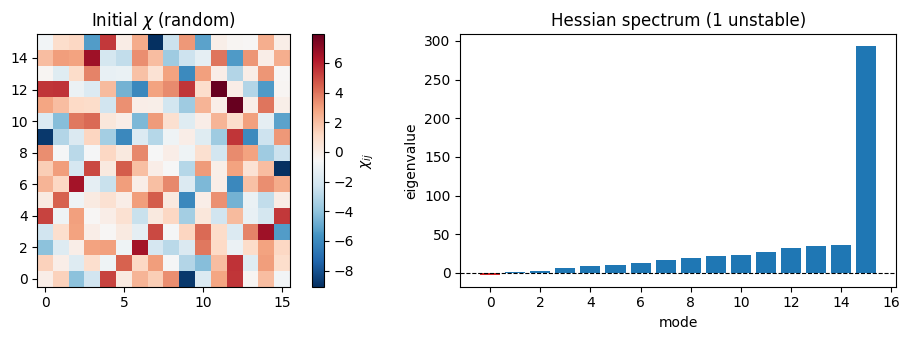

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

im = axes[0].imshow(chi_init_full, cmap='RdBu_r', origin='lower')
plt.colorbar(im, ax=axes[0], label=r'$\chi_{ij}$')
axes[0].set_title('Initial $\\chi$ (random)')

colors = ['tab:red' if e < 0 else 'tab:blue' for e in w_init]
axes[1].bar(range(N_COM), w_init, color=colors)
axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set_xlabel('mode')
axes[1].set_ylabel('eigenvalue')
axes[1].set_title(f'Hessian spectrum ({n_neg_init} unstable)')
fig.tight_layout()
plt.show()

## 2. Stage 1: spectral optimization

For $P$ phases, target $P-1$ unstable Hessian modes. The loss opens a margin around the unstable/stable eigenvalue split and adds mild $L_2$ regularization on $\chi$.

In [7]:
MARGIN = 0.5

@jax.jit
def spectral_loss(upper_tri):
    chi = chi_from_upper(upper_tri)
    J = compute_jacobian(N_COM, BETA, chi, chi_s_zero, r_ones)
    w = jnp.linalg.eigvalsh(J)  # ascending

    # Boundary: gap between last unstable and first stable eigenvalue
    loss_gap = (jax.nn.softplus(w[TARGET_NEG - 1] + MARGIN)
                + jax.nn.softplus(-(w[TARGET_NEG] - MARGIN)))

    # Push all target-unstable eigenvalues firmly negative
    loss_unstable = jnp.sum(jax.nn.softplus(w[:TARGET_NEG] + 1.0))

    reg = 1e-4 * jnp.sum(upper_tri ** 2)
    return loss_gap + 0.1 * loss_unstable + reg

spectral_value_and_grad = jax.jit(jax.value_and_grad(spectral_loss))

In [8]:
import optax

In [9]:
N_SPECTRAL_ITERS = 300
spectral_opt = optax.adam(learning_rate=0.05)

upper_tri = upper_init.copy()
opt_state = spectral_opt.init(upper_tri)
loss_history = []
neg_count_history = []
best_spectral_loss = float('inf')
best_upper_tri = upper_tri.copy()

for i in range(N_SPECTRAL_ITERS):
    loss_val, grad = spectral_value_and_grad(upper_tri)
    updates, opt_state = spectral_opt.update(grad, opt_state)
    upper_tri = optax.apply_updates(upper_tri, updates)

    lv = float(loss_val)
    loss_history.append(lv)
    if lv < best_spectral_loss:
        best_spectral_loss = lv
        best_upper_tri = upper_tri.copy()

    if i % 50 == 0 or i == N_SPECTRAL_ITERS - 1:
        chi_curr = chi_from_upper(upper_tri)
        J_curr = compute_jacobian(N_COM, BETA, chi_curr, chi_s_zero, r_ones)
        w_curr = jnp.linalg.eigvalsh(J_curr)
        n_neg = int(jnp.sum(w_curr < 0))
        neg_count_history.append((i, n_neg))
        print(f'iter {i:4d}  loss={lv:.4f}  unstable={n_neg}')

upper_tri = best_upper_tri
print(f'\nDone.  Best spectral loss: {best_spectral_loss:.4f}')

iter    0  loss=11.4084  unstable=1
iter   50  loss=0.3888  unstable=5
iter  100  loss=0.2616  unstable=5
iter  150  loss=0.2507  unstable=5
iter  200  loss=0.2455  unstable=5
iter  250  loss=0.2420  unstable=5
iter  299  loss=0.2392  unstable=5

Done.


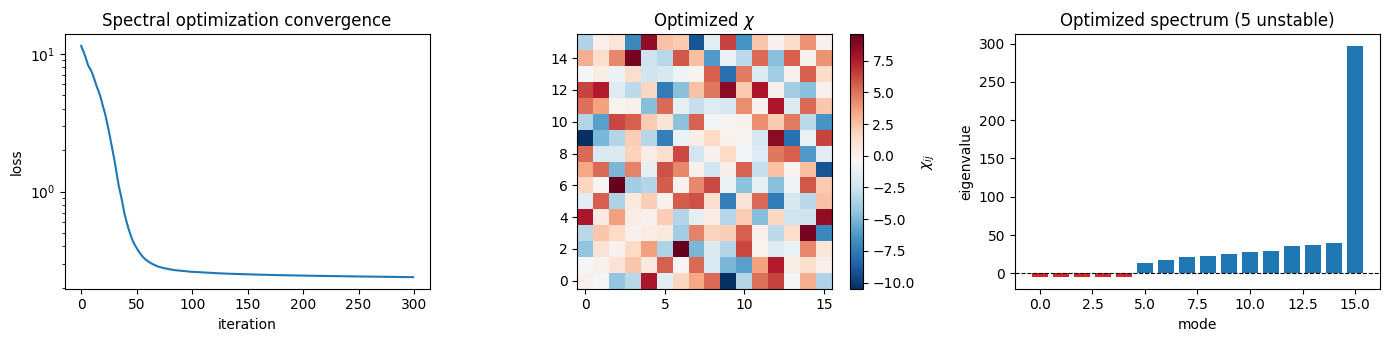

In [10]:
chi_opt = chi_from_upper(upper_tri)
J_opt = compute_jacobian(N_COM, BETA, chi_opt, chi_s_zero, r_ones)
w_opt = jnp.linalg.eigvalsh(J_opt)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].semilogy(loss_history)
axes[0].set_xlabel('iteration')
axes[0].set_ylabel('loss')
axes[0].set_title('Spectral optimization convergence')

im = axes[1].imshow(chi_opt, cmap='RdBu_r', origin='lower')
plt.colorbar(im, ax=axes[1], label=r'$\chi_{ij}$')
axes[1].set_title('Optimized $\\chi$')

colors_opt = ['tab:red' if e < 0 else 'tab:blue' for e in w_opt]
axes[2].bar(range(N_COM), w_opt, color=colors_opt)
axes[2].axhline(0, color='k', lw=0.8, ls='--')
axes[2].set_xlabel('mode')
axes[2].set_ylabel('eigenvalue')
axes[2].set_title(f'Optimized spectrum ({int(jnp.sum(w_opt < 0))} unstable)')
fig.tight_layout()
plt.show()

## 3. Verify with simulation

Run the full nonlinear simulation with the spectrally-optimized $\chi$
and check how many phases actually form.

In [11]:
c0 = generate_initial_conditions(N_COM, N_GRID, beta=BETA, noise_strength=0.01, key=k_ic)

def make_params(chi):
    """Build SimulationParams from chi (JAX-traceable, for use inside grad)."""
    kappa = jnp.eye(N_COM) * 1.0
    chi_s = jnp.zeros((N_COM, N_COM))
    r = jnp.ones((N_COM, 1))
    A = jnp.max(jnp.abs(chi)) * LMBDA
    return SimulationParams(
        chi=chi, kappa=kappa, chi_s=chi_s, r=r,
        lmbda=LMBDA, dt=DT, kon=0.0, koff=0.0, A=A,
    )

params_opt = make_params(chi_opt)
print(f'Stabilisation A = {float(params_opt.A):.6f}')

Stabilisation A = 0.1049


In [12]:
%%time
N_STEPS_VERIFY = 200_000
c_final_opt, snaps_opt = simulate_with_snapshots(
    c0, params_opt, N_GRID, N_STEPS_VERIFY, save_every=1_000, progress_bar=True,
)
jax.block_until_ready(c_final_opt)

Running for 200 iterations:   0%|          | 0/200 [00:00<?, ?it/s]

CPU times: user 32.6 s, sys: 6.78 s, total: 39.4 s
Wall time: 39.9 s


Array([[[0.09058186, 0.12078859, 0.15232117, ..., 0.03212433,
         0.04528413, 0.06483204],
        [0.066302  , 0.09392986, 0.12567231, ..., 0.0217845 ,
         0.03051263, 0.04502661],
        [0.04650209, 0.06988235, 0.09956454, ..., 0.01519345,
         0.02046573, 0.03032651],
        ...,
        [0.16664597, 0.19294019, 0.21399142, ..., 0.07889053,
         0.1065768 , 0.13689998],
        [0.14374474, 0.17281613, 0.19810168, ..., 0.06273539,
         0.08587031, 0.11372098],
        [0.11737791, 0.14801328, 0.17715827, ..., 0.04624841,
         0.06439141, 0.08859156]],

       [[0.02654124, 0.03224416, 0.03717233, ..., 0.01376871,
         0.01673903, 0.02111902],
        [0.02077738, 0.02688313, 0.03301882, ..., 0.00950725,
         0.01184994, 0.0156178 ],
        [0.0157035 , 0.02154711, 0.02819825, ..., 0.00676799,
         0.00839659, 0.01128754],
        ...,
        [0.03893838, 0.04038355, 0.0401408 , ..., 0.02846454,
         0.03213741, 0.0359573 ],
        [0.0

Detected phases: 5  (target: 6)


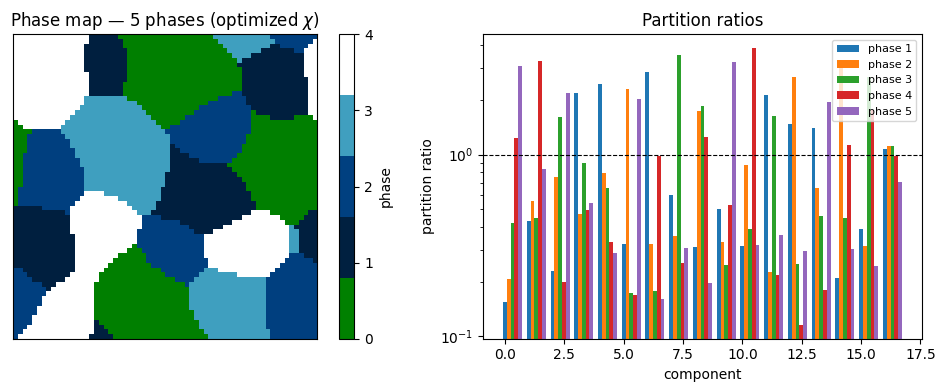

In [13]:
result_opt = analyse_snapshot(np.array(c_final_opt))
print(f"Detected phases: {result_opt['n_phases']}  (target: {TARGET_PHASES})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_phase_map(result_opt['labels'], result_opt['n_phases'], ax=axes[0])
axes[0].set_title(f"Phase map — {result_opt['n_phases']} phases (optimized $\\chi$)")
plot_partition_ratios(result_opt['partitions'], ax=axes[1])
axes[1].set_title('Partition ratios')
fig.tight_layout()
plt.show()

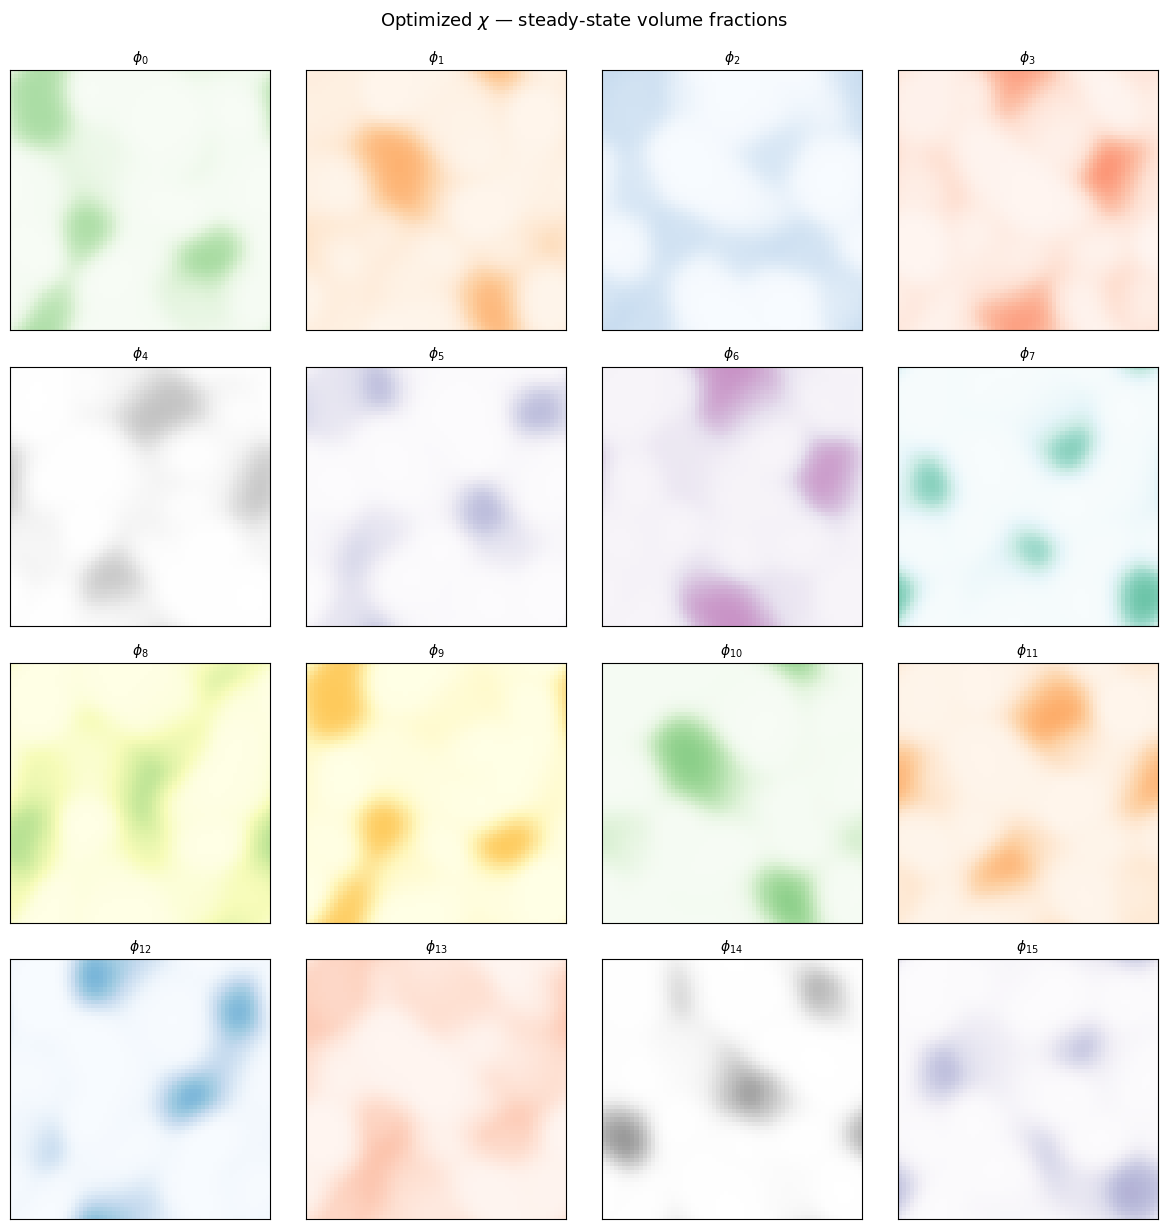

In [14]:
fig, _ = plot_volume_fractions(c_final_opt, ncols=4, vmax=0.75)
fig.suptitle(f'Optimized $\\chi$ — steady-state volume fractions', y=1.02, fontsize=13)
plt.show()

## 4. Stage 2: simulation-based refinement

Differentiate a soft phase-count proxy through the simulation. The scan is chunked with `jax.checkpoint` to reduce peak memory during backpropagation.

In [15]:
N_GRID_OPT = 32
N_STEPS_OPT = 20_000
CHUNK_SIZE = 200           # steps per checkpoint segment
N_CHUNKS = N_STEPS_OPT // CHUNK_SIZE
PHASE_THRESH = 9e-3
SIGMOID_TEMP = 1000.0

c0_small = generate_initial_conditions(
    N_COM, N_GRID_OPT, beta=BETA, noise_strength=0.01, key=k_ic,
)

from jax_phase_separation.solver import _make_step_fn, make_wavenumbers
from jax_tqdm import scan_tqdm

def soft_phase_count(c):
    """Differentiable proxy for number of coexisting phases."""
    c_sol = jnp.maximum(1.0 - jnp.sum(c, axis=0, keepdims=True), 1e-30)
    c_all = jnp.concatenate([c, c_sol], axis=0)
    N_ch = c_all.shape[0]
    flat = c_all.reshape(N_ch, -1).T

    mean = flat.mean(axis=0)
    std = jnp.maximum(flat.std(axis=0), 1e-12)
    centered = (flat - mean) / std

    cov = centered.T @ centered / (centered.shape[0] - 1)
    eigvals = jnp.linalg.eigvalsh(cov)[::-1]
    return jnp.sum(jax.nn.sigmoid(SIGMOID_TEMP * (eigvals - PHASE_THRESH)))


def _spectral_reg(upper_tri):
    """Lightweight spectral regularization (no @jax.jit, safe inside grad)."""
    chi = chi_from_upper(upper_tri)
    J = compute_jacobian(N_COM, BETA, chi, chi_s_zero, r_ones)
    w = jnp.linalg.eigvalsh(J)
    loss_gap = (jax.nn.softplus(w[TARGET_NEG - 1] + MARGIN)
                + jax.nn.softplus(-(w[TARGET_NEG] - MARGIN)))
    return loss_gap + 1e-4 * jnp.sum(upper_tri ** 2)


def sim_loss(upper_tri):
    chi = chi_from_upper(upper_tri)
    params = make_params(chi)

    # Checkpoint chunked scan to reduce backprop memory.
    wn = make_wavenumbers(N_GRID_OPT)
    Ainv = 1.0 / (1.0 + params.A * wn["k4"] * params.dt)
    cHat0 = jnp.fft.fftn(c0_small, axes=(-2, -1))
    inner_step = _make_step_fn(params, wn, Ainv, False)

    @scan_tqdm(N_CHUNKS, print_rate=max(1, N_CHUNKS // 20))
    @jax.checkpoint
    def chunk(carry, x):
        carry, _ = jax.lax.scan(inner_step, carry, None, length=CHUNK_SIZE)
        return carry, None

    (c_final, _), _ = jax.lax.scan(
        chunk, (c0_small, cHat0), jnp.arange(N_CHUNKS), length=N_CHUNKS,
    )

    n_soft = soft_phase_count(c_final)
    return (n_soft - TARGET_PHASES) ** 2 + 0.1 * _spectral_reg(upper_tri)

sim_value_and_grad = jax.value_and_grad(sim_loss)

In [16]:
%%time
# Warm-up JIT compilation on first call.
# The progress bar covers the forward pass; the backward pass
# (gradient computation) takes a similar amount of time afterwards.
loss_v, grad_v = sim_value_and_grad(upper_tri)
jax.block_until_ready(grad_v)
print(f'Initial sim loss: {float(loss_v):.4f}')
print(f'Gradient norm: {float(jnp.linalg.norm(grad_v)):.4e}')

Running for 100 iterations:   0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/jax/_src/lax/lax.py:5473: ComplexWarning: Casting complex values to real discards the imaginary part
  x_bar = _convert_element_type(x_bar, x.aval.dtype, x.aval.weak_type)


Initial sim loss: 0.0749
Gradient norm: 2.0443e-02
CPU times: user 15.1 s, sys: 663 ms, total: 15.8 s
Wall time: 17.6 s


In [17]:
%%time
N_SIM_ITERS = 8
sim_schedule = optax.cosine_decay_schedule(init_value=0.005, decay_steps=N_SIM_ITERS, alpha=0.1)
sim_opt = optax.adam(learning_rate=sim_schedule)

upper_tri_sim = upper_tri.copy()
opt_state_sim = sim_opt.init(upper_tri_sim)
sim_loss_history = []
best_sim_loss = float('inf')
best_upper_tri_sim = upper_tri_sim.copy()

for i in range(N_SIM_ITERS):
    loss_val, grad = sim_value_and_grad(upper_tri_sim)
    jax.block_until_ready(grad)
    updates, opt_state_sim = sim_opt.update(grad, opt_state_sim)
    upper_tri_sim = optax.apply_updates(upper_tri_sim, updates)

    lr_now = float(sim_schedule(opt_state_sim[1].count - 1))
    lv = float(loss_val)
    sim_loss_history.append(lv)
    if lv < best_sim_loss:
        best_sim_loss = lv
        best_upper_tri_sim = upper_tri_sim.copy()
        tag = ' *best*'
    else:
        tag = ''
    print(f'iter {i:2d}  lr={lr_now:.5f}  loss={lv:.4f}{tag}')

upper_tri_sim = best_upper_tri_sim
print(f'\nSimulation-based refinement complete.  Best loss: {best_sim_loss:.4f}')

Running for 100 iterations:   0%|          | 0/100 [00:00<?, ?it/s]

iter  0  loss=0.0749


Running for 100 iterations:   0%|          | 0/100 [00:00<?, ?it/s]

iter  1  loss=0.0680


Running for 100 iterations:   0%|          | 0/100 [00:00<?, ?it/s]

...

iter  5  loss=0.0263


Running for 100 iterations:   0%|          | 0/100 [00:00<?, ?it/s]

iter  6  loss=0.0240


Running for 100 iterations:   0%|          | 0/100 [00:00<?, ?it/s]

iter  7  loss=0.0288

Simulation-based refinement complete.
CPU times: user 1min 15s, sys: 3.65 s, total: 1min 19s
Wall time: 1min 21s


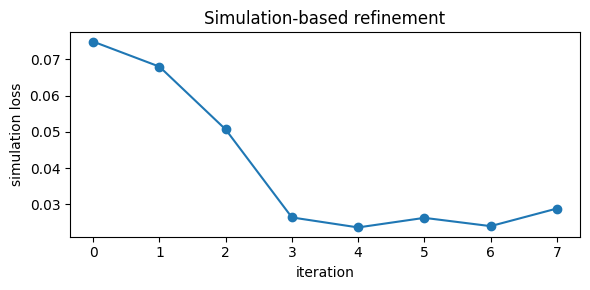

In [18]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(sim_loss_history, 'o-')
ax.set_xlabel('iteration')
ax.set_ylabel('simulation loss')
ax.set_title('Simulation-based refinement')
fig.tight_layout()
plt.show()

## 5. Final verification

Run a long simulation at full resolution with the refined $\chi$ and
compare against the initial random matrix.

In [19]:
%%time
chi_refined = chi_from_upper(upper_tri_sim)
params_refined = make_params(chi_refined)
c_final_refined = simulate(
    c0, params_refined, N_GRID, N_STEPS_VERIFY, progress_bar=True,
)
jax.block_until_ready(c_final_refined)

CPU times: user 31.4 s, sys: 5.23 s, total: 36.7 s
Wall time: 37 s


Array([[[0.05680591, 0.05989712, 0.0638735 , ..., 0.05169141,
         0.05283757, 0.0544988 ],
        [0.06700537, 0.07046253, 0.07488951, ..., 0.06176114,
         0.06277123, 0.06447928],
        [0.07199432, 0.07576481, 0.08062637, ..., 0.06697728,
         0.06769445, 0.06933218],
        ...,
        [0.02200907, 0.0233488 , 0.025132  , ..., 0.01961742,
         0.02022471, 0.02099524],
        [0.03180595, 0.03379708, 0.03642614, ..., 0.02829478,
         0.02917103, 0.03030497],
        [0.04409023, 0.0466966 , 0.0500893 , ..., 0.03958012,
         0.04066806, 0.04212882]],

       [[0.01495837, 0.01781643, 0.02304505, ..., 0.01239334,
         0.01267177, 0.01344011],
        [0.01733026, 0.02058794, 0.02653519, ..., 0.01466005,
         0.01484064, 0.01563531],
        [0.01821634, 0.02160016, 0.02782682, ..., 0.01575819,
         0.01577861, 0.01650279],
        ...,
        [0.00717164, 0.00844224, 0.01073049, ..., 0.005803  ,
         0.00602722, 0.00645194],
        [0.0

In [20]:
result_refined = analyse_snapshot(np.array(c_final_refined))
print(f"Refined chi  → {result_refined['n_phases']} phases  (target: {TARGET_PHASES})")

Refined chi  → 4 phases  (target: 6)


In [21]:
%%time
# Baseline: simulation with the initial random chi
from jax_phase_separation.utils import build_params
params_init = build_params(chi_init_full, N_COM, beta=BETA, lmbda=LMBDA, dt=DT)
c_final_init = simulate(c0, params_init, N_GRID, N_STEPS_VERIFY, progress_bar=True)
jax.block_until_ready(c_final_init)
result_init = analyse_snapshot(np.array(c_final_init))
print(f"Random chi   → {result_init['n_phases']} phases")

Random chi   → 1 phases
CPU times: user 32.2 s, sys: 5.1 s, total: 37.3 s
Wall time: 37.7 s


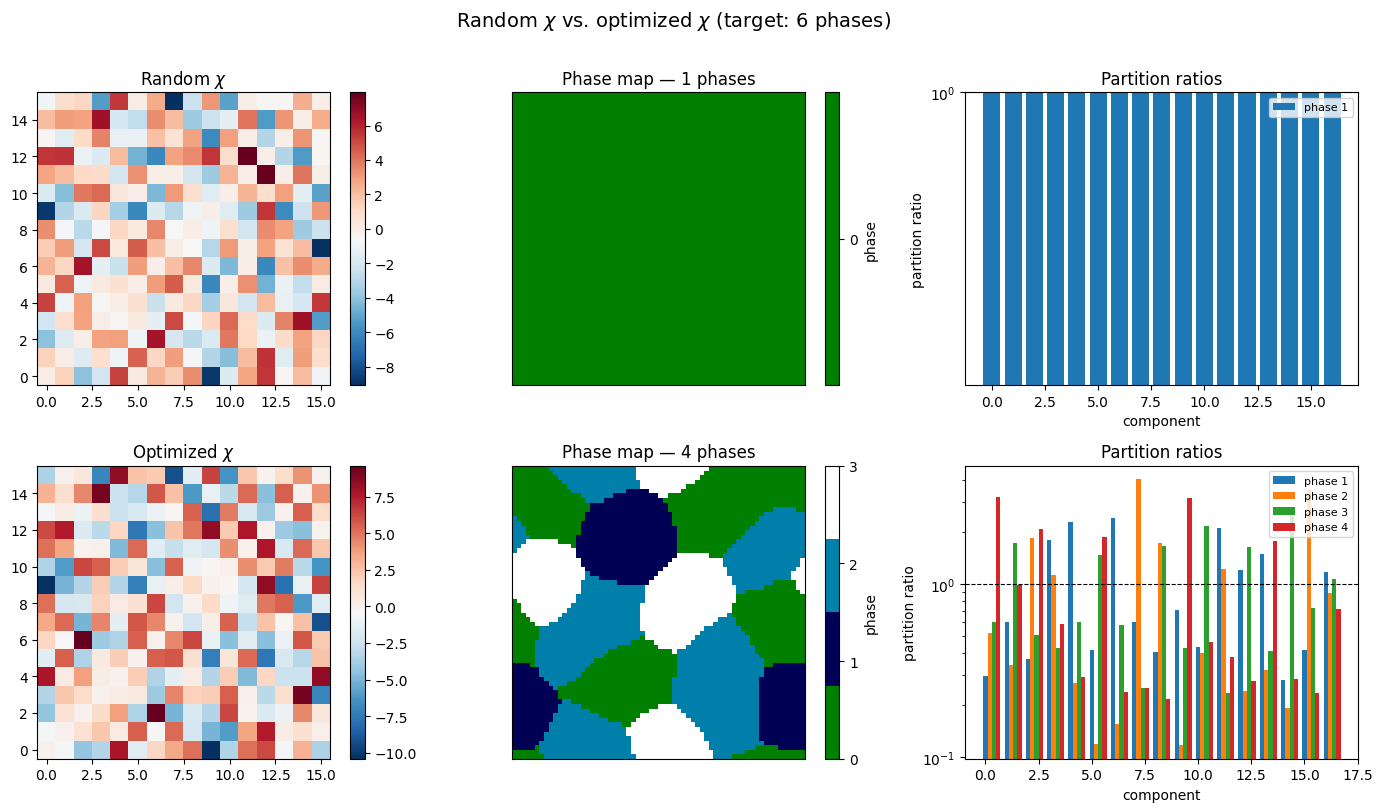

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# --- Top row: random chi ---
im0 = axes[0, 0].imshow(chi_init_full, cmap='RdBu_r', origin='lower')
plt.colorbar(im0, ax=axes[0, 0])
axes[0, 0].set_title('Random $\\chi$')

plot_phase_map(result_init['labels'], result_init['n_phases'], ax=axes[0, 1])
axes[0, 1].set_title(f"Phase map — {result_init['n_phases']} phases")

plot_partition_ratios(result_init['partitions'], ax=axes[0, 2])
axes[0, 2].set_title('Partition ratios')

# --- Bottom row: optimized chi ---
im1 = axes[1, 0].imshow(chi_refined, cmap='RdBu_r', origin='lower')
plt.colorbar(im1, ax=axes[1, 0])
axes[1, 0].set_title('Optimized $\\chi$')

plot_phase_map(result_refined['labels'], result_refined['n_phases'], ax=axes[1, 1])
axes[1, 1].set_title(f"Phase map — {result_refined['n_phases']} phases")

plot_partition_ratios(result_refined['partitions'], ax=axes[1, 2])
axes[1, 2].set_title('Partition ratios')

fig.suptitle(f'Random $\\chi$ vs. optimized $\\chi$ (target: {TARGET_PHASES} phases)',
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

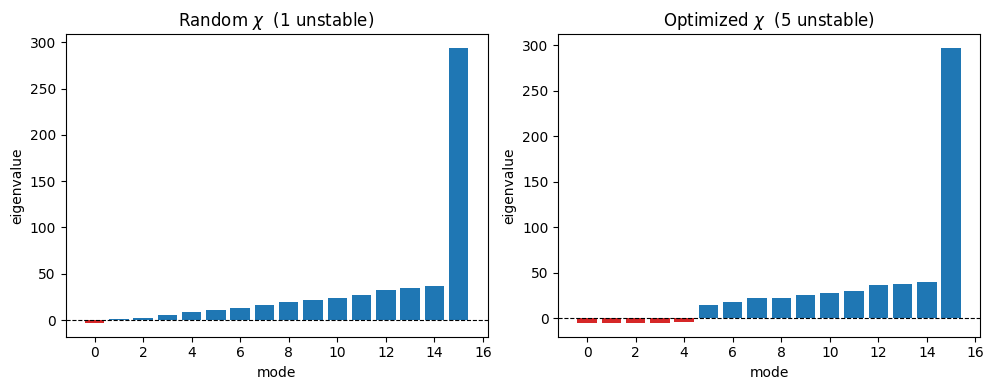

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

w_refined = jnp.linalg.eigvalsh(
    compute_jacobian(N_COM, BETA, chi_refined, chi_s_zero, r_ones)
)

for ax, w, title in zip(axes, [w_init, w_refined], ['Random $\\chi$', 'Optimized $\\chi$']):
    colors = ['tab:red' if e < 0 else 'tab:blue' for e in w]
    ax.bar(range(N_COM), w, color=colors)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('mode')
    ax.set_ylabel('eigenvalue')
    n = int(jnp.sum(jnp.array(w) < 0))
    ax.set_title(f'{title}  ({n} unstable)')

fig.tight_layout()
plt.show()